# DEGs comparisons
I compared the DEGs identified from pairwise comparisons of isolated treatments in [DEGs_overlap.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/DEGs_overlap.ipynb), but I'm also interested in looking more closely at DEGs and compare across phase 1 and phase 2 oysters. 

I've hypothesized that younger oysters will be more plastic than older oysters, and so I would expect to see more DEGs in phase 1 oysters compared to phase 2.

## 1. load libraries

In [2]:
library(tidyverse)

## 2. load csvs

### A. phase 1 oysters

In [13]:
# get list of files
p1.files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res',
    pattern = "^p1.*\\.csv$",
    full.names = TRUE
    )

head(p1.files)

names(p1.files) <- gsub('p1.', '', tools::file_path_sans_ext(basename(p1.files)))
p1.files <- lapply(p1.files, read.csv)
names(p1.files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.both_v_cont.csv"
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.hyp_v_both.csv" 
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.hyp_v_cont.csv" 
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.hyp_v_warm.csv" 
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.warm_v_both.csv"
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.warm_v_cont.csv"

[1] "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm"  "warm_v_both"
[6] "warm_v_cont"

#### pull out DEGs

In [17]:
p1.deg <- lapply(p1.files, function(df) {
  df %>% filter(abs(log2FoldChange) >= "1" & padj <= 0.05)
})

names(p1.deg)
head(p1.deg$both_v_cont)

[1] "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm"  "warm_v_both"
[6] "warm_v_cont"

,X,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3,LOC111120925,191.44305,-4.816061,1.434592,-4.432787,9.302274e-06,0.0030326606,0.003332593,3.429848,⋯,383.261217,14.374893,246.710448,219.685794,6.742502,337.801055,5.5715422,6.466452,0.000000,13.843829
2,211,LOC111103173,15.14959,4.365504,2.025135,4.039598,5.354287e-05,0.0106991246,0.022951093,129.476769,⋯,2.546586,6.708283,1.036599,2.630968,10.488336,0.000000,0.9285904,16.628020,0.000000,0.000000
3,232,LOC144622019,14.43126,-21.685053,4.272431,-5.354808,8.564740e-08,0.0000483984,0.000161978,0.000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
4,327,LOC111105159,57.17908,-5.199942,2.588591,-4.075872,4.584228e-05,0.0096385781,0.027797446,0.000000,⋯,1.273293,1.916652,1.036599,2.630968,1.498334,3.568321,0.0000000,3.695116,1.984959,0.000000
5,510,LOC111132252,110.19476,-2.635506,2.006382,-3.633249,2.798748e-04,0.0327889602,0.092730666,0.000000,⋯,146.428704,32.583090,350.370300,388.067720,35.210841,114.186272,43.6437471,15.704241,248.119838,3.775590
6,516,LOC111137262,591.06709,3.622591,3.009049,3.696540,2.185576e-04,0.0280691987,0.102579351,1.714924,⋯,2942.580305,1106.866737,13.475781,0.000000,4.495001,2653.641385,1.8571807,2366.721529,6.947355,7.551179


#### format df for plotting

In [34]:
p1.deg2 <- Map(
  function(df, name) {
    
    # add df name column
    df$pair <- name
    
    # DEG assignment based on LFC direction
    df$DEG_group <- ifelse(
      df$log2FoldChange > 0,
      toupper(substr(sub("_.*", "", df$pair), 1, 1)),
      toupper(substr(sub(".*_", "", df$pair), 1, 1))
    )

    # add phase 1 column
    df$phase <- 'Phase 1'
      
    df
  },
  p1.deg,
  names(p1.deg)
)

p1.deg2 <- lapply(p1.deg2, function(df) {
# select only the necessary columns
  select(df, c(Gene, log2FoldChange, padj, pair, DEG_group, phase))
})

head(p1.deg2$both_v_cont)

,Gene,log2FoldChange,padj,pair,DEG_group,phase
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC111120925,-4.816061,0.0030326606,both_v_cont,C,Phase 1
2,LOC111103173,4.365504,0.0106991246,both_v_cont,B,Phase 1
3,LOC144622019,-21.685053,0.0000483984,both_v_cont,C,Phase 1
4,LOC111105159,-5.199942,0.0096385781,both_v_cont,C,Phase 1
5,LOC111132252,-2.635506,0.0327889602,both_v_cont,C,Phase 1
6,LOC111137262,3.622591,0.0280691987,both_v_cont,B,Phase 1


In [ ]:
p2.deg2 <- lapply(p2.deg, function(df) {
# select only the necessary columns
  select(df, c(Gene, log2FoldChange, padj, pair, DEG_group, phase))
})

### B. phase 2 oysters

In [3]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/DEGs',
    pattern = '\\.csv$',
    full.names = TRUE
    )

head(files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/DEGs/DEG_bb_cc.csv"
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/DEGs/DEG_bc_bb.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/DEGs/DEG_bc_cc.csv"
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/DEGs/DEG_bc_hc.csv"
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/DEGs/DEG_bc_wc.csv"
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/DEGs/DEG_bh_ch.csv"

In [5]:
names(files) <- gsub('DEG_', '', tools::file_path_sans_ext(basename(files)))
p2.deg <- lapply(files, read.csv)
names(p2.deg)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

In [30]:
p2.deg2 <- lapply(p2.deg, function(df) {
  # add column to denote phase 2
    df$phase <- "Phase 2"

# select only the necessary columns
  select(df, c(Gene, log2FoldChange, padj, pair, DEG_group, phase))
})

In [31]:
head(p2.deg2$bb_cc)

,Gene,log2FoldChange,padj,pair,DEG_group,phase
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC111102506,1.113463,4.376733e-02,CC vs. BB,BB,Phase 2
2,LOC111117765,1.019382,1.923475e-02,CC vs. BB,BB,Phase 2
3,LOC111104782,1.360622,2.436630e-02,CC vs. BB,BB,Phase 2
4,LOC144619911,-3.777067,2.349671e-02,CC vs. BB,CC,Phase 2
5,LOC111105268,-1.988343,2.795036e-02,CC vs. BB,CC,Phase 2
6,LOC111102028,21.008371,2.961740e-07,CC vs. BB,BB,Phase 2


### C. merge dfs for plotting

In [38]:
deg.all <- bind_rows(c(p1.deg2, p2.deg2))
head(deg.all)

,Gene,log2FoldChange,padj,pair,DEG_group,phase
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC111120925,-4.816061,0.0030326606,both_v_cont,C,Phase 1
2,LOC111103173,4.365504,0.0106991246,both_v_cont,B,Phase 1
3,LOC144622019,-21.685053,0.0000483984,both_v_cont,C,Phase 1
4,LOC111105159,-5.199942,0.0096385781,both_v_cont,C,Phase 1
5,LOC111132252,-2.635506,0.0327889602,both_v_cont,C,Phase 1
6,LOC111137262,3.622591,0.0280691987,both_v_cont,B,Phase 1


## 3. plot DEGs per comparison

### barplot of all DEGs

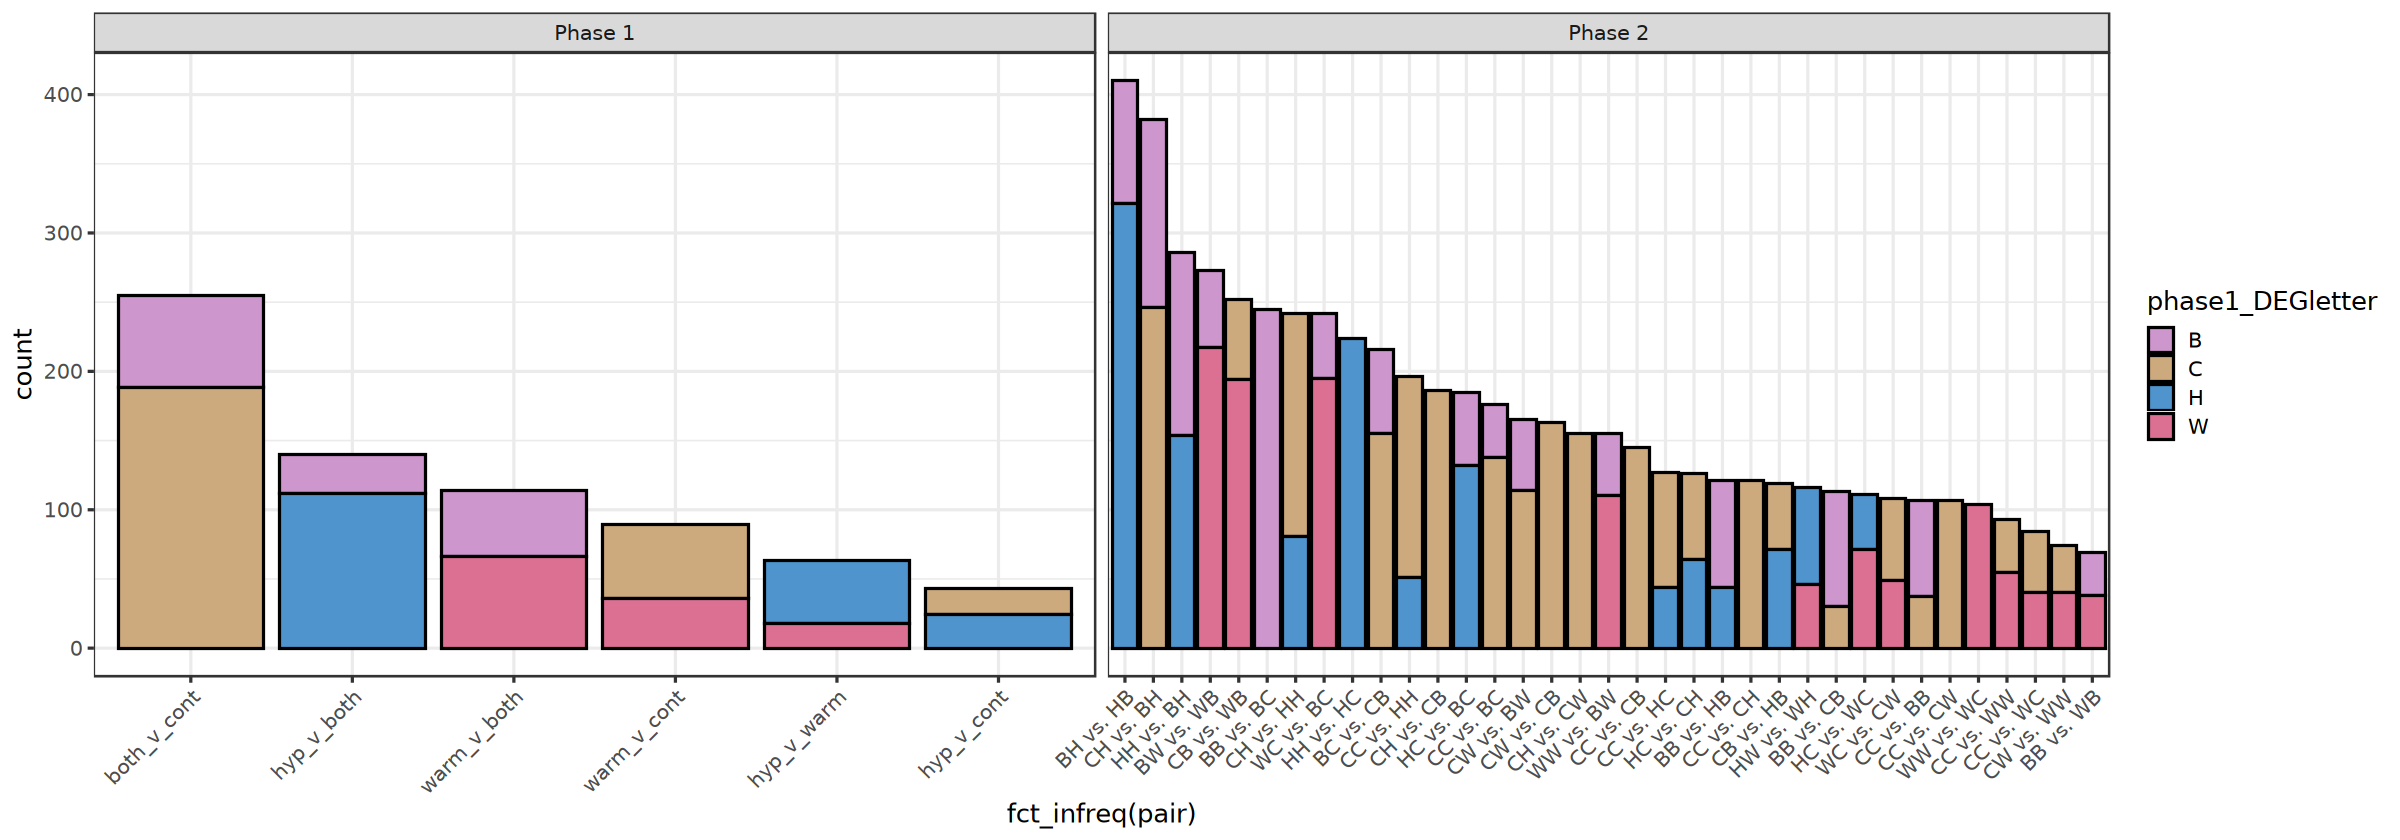

In [55]:
options(repr.plot.height = 7, repr.plot.width = 20)

deg.all <- deg.all %>%
  mutate(phase1_DEGletter = substr(DEG_group, 1, 1))

ggplot(deg.all, aes(x = fct_infreq(pair), fill = phase1_DEGletter)) +
  geom_bar(stat = "count", col = 'black') +
  facet_wrap(~ phase, scales = "free_x") +
  scale_fill_manual(values = c(
    C = "burlywood3",
    H = "steelblue3",
    B = "plum3",
    W = "palevioletred"
  )) +
  theme_bw(base_size = 15) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

okay so the only problem with this is if a comparison shares the same phase 1, then it looks like all one bar instead of split by the two comparisons but anyways

it looks like overall, there are less DEGs in the phase 1 samples compared to the phase 2 samples but I haven't statistically tested this yet

**phase 1**: the comparisons with the most DEGs are those with oysters that experienced both stressors (which makes sense - maybe an additive or interactive effect of the two stressors) - but looks like most of the time the genes are downregulated in both (so higher expression in the other treatment)

**phase 2**: looks similar to phase 1 in that we see more purple (comparisons with phase 1 both) in the comparisons with the majority of DEGs

### boxplot of number of DEGs

In [59]:
# count the number of DEGs per comparison
deg.count <- deg.all %>%
count(pair, phase)

head(deg.count)

,pair,phase,n
,<chr>,<chr>,<int>
1,BB vs. BC,Phase 2,245
2,BB vs. CB,Phase 2,113
3,BB vs. HB,Phase 2,121
4,BB vs. WB,Phase 2,69
5,BC vs. CB,Phase 2,216
6,BH vs. HB,Phase 2,410


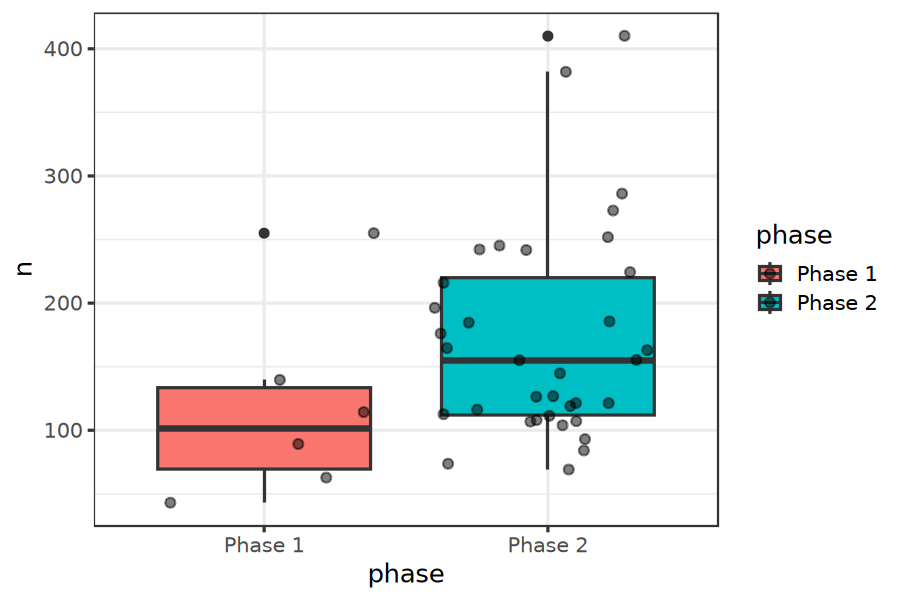

In [71]:
options(repr.plot.width = 7.5, repr.plot.height = 5)

ggplot(deg.count, aes(x = phase, y = n, fill = phase)) +
geom_boxplot() +
geom_jitter(alpha = 0.5) +
theme_bw(base_size = 15)

In [72]:
deg.aov <- aov(n ~ phase, data = deg.count)
summary(deg.aov)

            Df Sum Sq Mean Sq F value Pr(>F)
phase        1  14957   14957   2.287  0.139
Residuals   39 255106    6541               

so while there appears to be more DEGs in phase 2 oysters, it's not significantly more than phase 1 oysters (p = 0.139)